In [1]:
import sys
import os
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from InstructorEmbedding import INSTRUCTOR

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Models: GTR-T5 vs INSTRUCTOR

Chúng ta sẽ so sánh 2 models **pretrained sẵn**:

1. **GTR-T5** (`sentence-transformers/gtr-t5-large`): 
   - Backbone của INSTRUCTOR
   - Không sử dụng instruction
   - Encode text thuần túy

2. **INSTRUCTOR** (`hkunlp/instructor-large`):
   - Model pretrained bởi HKUNLP
   - Sử dụng instruction để điều kiện hóa embedding
   - Cùng architecture với GTR-T5 nhưng được fine-tune với instructions

In [2]:
print("Đang load models pretrained...")
print("(Lần đầu có thể download ~1-2GB mỗi model)\n")

print("[1/2] Loading GTR-T5 (sentence-transformers/gtr-t5-large)...")
gtr_model = SentenceTransformer('sentence-transformers/gtr-t5-large')
print("      ✅ GTR-T5 loaded!")

print("[2/2] Loading INSTRUCTOR (hkunlp/instructor-large)...")
instructor_model = INSTRUCTOR('hkunlp/instructor-large')
print("      ✅ INSTRUCTOR loaded!")

print("\n" + "=" * 60)
print("MODELS ĐÃ LOAD:")
print("=" * 60)
print("📦 GTR-T5:     Backbone, encode text thuần (không instruction)")
print("📦 INSTRUCTOR: Encode [instruction, text] (có instruction)")
print("=" * 60)

Đang load models pretrained...
(Lần đầu có thể download ~1-2GB mỗi model)

[1/2] Loading GTR-T5 (sentence-transformers/gtr-t5-large)...


c:\Users\Admin\miniconda3\envs\instructor\lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


      ✅ GTR-T5 loaded!
[2/2] Loading INSTRUCTOR (hkunlp/instructor-large)...
      ✅ INSTRUCTOR loaded!

MODELS ĐÃ LOAD:
📦 GTR-T5:     Backbone, encode text thuần (không instruction)
📦 INSTRUCTOR: Encode [instruction, text] (có instruction)


## Demo 1: GTR-T5 vs INSTRUCTOR - Document Retrieval

**So sánh trực tiếp**:
- **GTR-T5**: Encode query và documents như text thuần túy
- **INSTRUCTOR**: Encode với instruction mô tả task retrieval

Cùng một query, cùng corpus documents → xem model nào retrieval tốt hơn.

In [3]:
documents = [
    "Python is a programming language known for its simple syntax.",
    "Machine learning algorithms can learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Neural networks are inspired by the human brain.",
    "Climate change is affecting global weather patterns.",
    "Deep learning is a subset of machine learning using neural networks.",
]

query = "How do neural networks learn?"

query_emb_gtr = gtr_model.encode([query])
doc_embs_gtr = gtr_model.encode(documents)

query_instruction = "Represent the question for retrieving supporting documents:"
doc_instruction = "Represent the document for retrieval:"

query_emb_inst = instructor_model.encode([[query_instruction, query]])
doc_embs_inst = instructor_model.encode([[doc_instruction, doc] for doc in documents])

print("Query:", query)
print("\nDocuments:")
for i, doc in enumerate(documents):
    print(f"  {i}: {doc}")

Query: How do neural networks learn?

Documents:
  0: Python is a programming language known for its simple syntax.
  1: Machine learning algorithms can learn patterns from data.
  2: The Eiffel Tower is located in Paris, France.
  3: Neural networks are inspired by the human brain.
  4: Climate change is affecting global weather patterns.
  5: Deep learning is a subset of machine learning using neural networks.


In [4]:
sim_gtr = cosine_similarity(query_emb_gtr, doc_embs_gtr)[0]
sim_inst = cosine_similarity(query_emb_inst, doc_embs_inst)[0]

ranked_gtr = sorted(enumerate(sim_gtr), key=lambda x: x[1], reverse=True)
ranked_inst = sorted(enumerate(sim_inst), key=lambda x: x[1], reverse=True)

print("=" * 80)
print("SO SÁNH: GTR-T5 (No Instruction) vs INSTRUCTOR (With Instruction)")
print("=" * 80)
print(f"\nQuery: \"{query}\"")

print("\n" + "-" * 80)
print(f"{'GTR-T5 (No Instruction)':<40} | {'INSTRUCTOR (With Instruction)':>35}")
print("-" * 80)

for i in range(len(documents)):
    idx_g, score_g = ranked_gtr[i]
    idx_i, score_i = ranked_inst[i]
    doc_g = documents[idx_g][:30] + "..."
    doc_i = documents[idx_i][:30] + "..."
    print(f"#{i+1} {score_g:.3f}: {doc_g:<32} | #{i+1} {score_i:.3f}: {doc_i}")

print("\n" + "=" * 80)
print("PHÂN TÍCH:")
print("=" * 80)
print("→ GTR-T5: Encode text thuần, dựa vào semantic similarity chung")
print("→ INSTRUCTOR: Có instruction mô tả task retrieval → embedding phù hợp hơn cho task")

SO SÁNH: GTR-T5 (No Instruction) vs INSTRUCTOR (With Instruction)

Query: "How do neural networks learn?"

--------------------------------------------------------------------------------
GTR-T5 (No Instruction)                  |       INSTRUCTOR (With Instruction)
--------------------------------------------------------------------------------
#1 0.715: Neural networks are inspired b... | #1 0.878: Neural networks are inspired b...
#2 0.704: Machine learning algorithms ca... | #2 0.877: Machine learning algorithms ca...
#3 0.684: Deep learning is a subset of m... | #3 0.874: Deep learning is a subset of m...
#4 0.457: Python is a programming langua... | #4 0.736: Python is a programming langua...
#5 0.420: Climate change is affecting gl... | #5 0.687: The Eiffel Tower is located in...
#6 0.346: The Eiffel Tower is located in... | #6 0.686: Climate change is affecting gl...

PHÂN TÍCH:
→ GTR-T5: Encode text thuần, dựa vào semantic similarity chung
→ INSTRUCTOR: Có instruction mô tả ta

### Visualization: Heatmap so sánh

Trực quan hóa sự khác biệt trong similarity scores giữa có instruction và không có instruction.

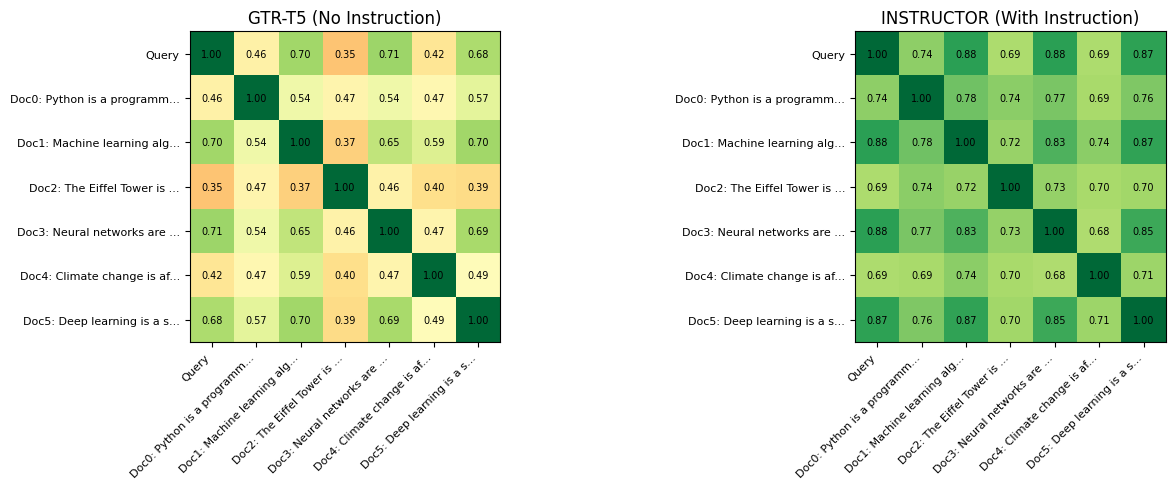


→ So sánh Query-Document similarities giữa 2 models!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

doc_labels = [f"Doc{i}: {doc[:20]}..." for i, doc in enumerate(documents)]

sim_matrix_gtr = cosine_similarity(
    np.vstack([query_emb_gtr, doc_embs_gtr]),
    np.vstack([query_emb_gtr, doc_embs_gtr])
)
labels_gtr = ["Query"] + doc_labels
im1 = axes[0].imshow(sim_matrix_gtr, cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_xticks(range(len(labels_gtr)))
axes[0].set_yticks(range(len(labels_gtr)))
axes[0].set_xticklabels(labels_gtr, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(labels_gtr, fontsize=8)
axes[0].set_title('GTR-T5 (No Instruction)', fontsize=12)
for i in range(len(labels_gtr)):
    for j in range(len(labels_gtr)):
        axes[0].text(j, i, f'{sim_matrix_gtr[i,j]:.2f}', ha='center', va='center', fontsize=7)

sim_matrix_inst = cosine_similarity(
    np.vstack([query_emb_inst, doc_embs_inst]),
    np.vstack([query_emb_inst, doc_embs_inst])
)
labels_inst = ["Query"] + doc_labels
im2 = axes[1].imshow(sim_matrix_inst, cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_xticks(range(len(labels_inst)))
axes[1].set_yticks(range(len(labels_inst)))
axes[1].set_xticklabels(labels_inst, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(labels_inst, fontsize=8)
axes[1].set_title('INSTRUCTOR (With Instruction)', fontsize=12)
for i in range(len(labels_inst)):
    for j in range(len(labels_inst)):
        axes[1].text(j, i, f'{sim_matrix_inst[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

print("\n→ So sánh Query-Document similarities giữa 2 models!")

## Demo 2: INSTRUCTOR với các Task-Specific Instructions

Điểm mạnh của INSTRUCTOR: **Cùng một text** có thể tạo **embeddings khác nhau** tùy theo instruction mô tả task.

GTR-T5 không có khả năng này - chỉ tạo một embedding duy nhất cho mỗi text.

In [6]:
text = "Machine learning is transforming how we analyze data"

emb_gtr = gtr_model.encode([text])[0]

task_instructions = {
    "retrieval_query": "Represent the question for retrieving relevant documents:",
    "retrieval_doc": "Represent the document for retrieval:",
    "classification": "Represent the sentence for classification:",
    "clustering": "Represent the sentence for clustering:",
    "similarity": "Represent the sentence for semantic similarity:",
}

embeddings_inst = {}
for task, instruction in task_instructions.items():
    embeddings_inst[task] = instructor_model.encode([[instruction, text]])[0]

print(f"Text: \"{text}\"\n")
print("=" * 60)
print("INSTRUCTOR: Similarity giữa các task-specific embeddings")
print("=" * 60)

tasks = list(task_instructions.keys())
print(f"\n{'Task 1':<20} {'Task 2':<20} {'Similarity':>12}")
print("-" * 55)
for i in range(len(tasks)):
    for j in range(i+1, len(tasks)):
        sim = cosine_similarity([embeddings_inst[tasks[i]]], 
                               [embeddings_inst[tasks[j]]])[0][0]
        print(f"{tasks[i]:<20} {tasks[j]:<20} {sim:>12.4f}")

print("\n→ Cùng text nhưng instruction khác → embedding khác!")
print("→ GTR-T5 không có khả năng này (chỉ 1 embedding/text)")

Text: "Machine learning is transforming how we analyze data"

INSTRUCTOR: Similarity giữa các task-specific embeddings

Task 1               Task 2                 Similarity
-------------------------------------------------------
retrieval_query      retrieval_doc              0.9936
retrieval_query      classification             0.9733
retrieval_query      clustering                 0.9739
retrieval_query      similarity                 0.9845
retrieval_doc        classification             0.9718
retrieval_doc        clustering                 0.9720
retrieval_doc        similarity                 0.9867
classification       clustering                 0.9953
classification       similarity                 0.9857
clustering           similarity                 0.9842

→ Cùng text nhưng instruction khác → embedding khác!
→ GTR-T5 không có khả năng này (chỉ 1 embedding/text)


## Demo 3: Retrieval Performance - GTR-T5 vs INSTRUCTOR

Test trên corpus lớn hơn để thấy rõ sự khác biệt về chất lượng retrieval.

In [7]:
documents_retrieval = [
    "Python is a programming language known for its simple syntax.",
    "Machine learning algorithms can learn patterns from data.",
    "The Eiffel Tower is located in Paris, France.",
    "Neural networks are inspired by the human brain.",
    "Climate change is affecting global weather patterns.",
    "Deep learning is a subset of machine learning.",
    "The Great Wall of China is a famous landmark.",
    "Natural language processing enables computers to understand text."
]

query_retrieval = "How do computers understand human language?"

query_emb_gtr_ret = gtr_model.encode([query_retrieval])
doc_embs_gtr_ret = gtr_model.encode(documents_retrieval)
sim_gtr_ret = cosine_similarity(query_emb_gtr_ret, doc_embs_gtr_ret)[0]
ranked_gtr_ret = sorted(enumerate(sim_gtr_ret), key=lambda x: x[1], reverse=True)

query_inst_ret = "Represent the question for retrieving supporting documents:"
doc_inst_ret = "Represent the document for retrieval:"

query_emb_inst_ret = instructor_model.encode([[query_inst_ret, query_retrieval]])
doc_embs_inst_ret = instructor_model.encode([[doc_inst_ret, doc] for doc in documents_retrieval])
sim_inst_ret = cosine_similarity(query_emb_inst_ret, doc_embs_inst_ret)[0]
ranked_inst_ret = sorted(enumerate(sim_inst_ret), key=lambda x: x[1], reverse=True)

print(f"Query: \"{query_retrieval}\"")
print("\n" + "=" * 85)
print(f"{'GTR-T5 (No Instruction)':^40} | {'INSTRUCTOR (With Instruction)':^40}")
print("=" * 85)

for i in range(len(documents_retrieval)):
    idx_g, score_g = ranked_gtr_ret[i]
    idx_i, score_i = ranked_inst_ret[i]
    marker_g = "✓" if "language" in documents_retrieval[idx_g].lower() or "text" in documents_retrieval[idx_g].lower() else " "
    marker_i = "✓" if "language" in documents_retrieval[idx_i].lower() or "text" in documents_retrieval[idx_i].lower() else " "
    doc_g = documents_retrieval[idx_g][:28] + "..."
    doc_i = documents_retrieval[idx_i][:28] + "..."
    print(f"#{i+1}[{marker_g}] {score_g:.3f}: {doc_g:<28} | #{i+1}[{marker_i}] {score_i:.3f}: {doc_i}")

Query: "How do computers understand human language?"

        GTR-T5 (No Instruction)          |      INSTRUCTOR (With Instruction)      
#1[✓] 0.770: Natural language processing ... | #1[✓] 0.904: Natural language processing ...
#2[ ] 0.616: Neural networks are inspired... | #2[ ] 0.841: Machine learning algorithms ...
#3[ ] 0.612: Machine learning algorithms ... | #3[ ] 0.825: Neural networks are inspired...
#4[✓] 0.587: Python is a programming lang... | #4[✓] 0.816: Python is a programming lang...
#5[ ] 0.558: Deep learning is a subset of... | #5[ ] 0.801: Deep learning is a subset of...
#6[ ] 0.441: The Great Wall of China is a... | #6[ ] 0.743: The Great Wall of China is a...
#7[ ] 0.417: Climate change is affecting ... | #7[ ] 0.735: The Eiffel Tower is located ...
#8[ ] 0.399: The Eiffel Tower is located ... | #8[ ] 0.697: Climate change is affecting ...


## Demo 4: Clustering - GTR-T5 vs INSTRUCTOR

So sánh khả năng clustering theo chủ đề giữa 2 models.

In [8]:
texts_cluster = [
    "The football match ended with a dramatic goal in overtime.",
    "Basketball players need excellent jumping abilities.",
    "Tennis requires both physical and mental strength.",
    "Artificial intelligence is transforming many industries.",
    "Quantum computing promises unprecedented processing power.",
    "Cybersecurity is essential in the digital age.",
    "Italian pasta dishes are popular worldwide.",
    "Sushi is a traditional Japanese cuisine.",
    "French pastries are known for their delicate flavors."
]

true_labels = [0, 0, 0, 1, 1, 1, 2, 2, 2]
label_names = ['Sports', 'Technology', 'Food']

emb_gtr_cluster = gtr_model.encode(texts_cluster)

cluster_instruction = "Represent the news article for topic clustering:"
emb_inst_cluster = instructor_model.encode([[cluster_instruction, t] for t in texts_cluster])

print("Texts for clustering (by topic):")
for i, (text, label) in enumerate(zip(texts_cluster, true_labels)):
    print(f"  [{label_names[label]}] {text[:50]}...")

Texts for clustering (by topic):
  [Sports] The football match ended with a dramatic goal in o...
  [Sports] Basketball players need excellent jumping abilitie...
  [Sports] Tennis requires both physical and mental strength....
  [Technology] Artificial intelligence is transforming many indus...
  [Technology] Quantum computing promises unprecedented processin...
  [Technology] Cybersecurity is essential in the digital age....
  [Food] Italian pasta dishes are popular worldwide....
  [Food] Sushi is a traditional Japanese cuisine....
  [Food] French pastries are known for their delicate flavo...


### Clustering Evaluation: GTR-T5 vs INSTRUCTOR

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

kmeans_gtr = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_gtr = kmeans_gtr.fit_predict(emb_gtr_cluster)
ari_gtr = adjusted_rand_score(true_labels, pred_gtr)
sil_gtr = silhouette_score(emb_gtr_cluster, pred_gtr)

kmeans_inst = KMeans(n_clusters=3, random_state=42, n_init=10)
pred_inst = kmeans_inst.fit_predict(emb_inst_cluster)
ari_inst = adjusted_rand_score(true_labels, pred_inst)
sil_inst = silhouette_score(emb_inst_cluster, pred_inst)

print("=" * 70)
print("CLUSTERING EVALUATION: GTR-T5 vs INSTRUCTOR")
print("=" * 70)
print(f"\n{'Metric':<25} {'GTR-T5':>15} {'INSTRUCTOR':>15} {'Δ':>12}")
print("-" * 70)
print(f"{'Adjusted Rand Index':<25} {ari_gtr:>15.4f} {ari_inst:>15.4f} {ari_inst-ari_gtr:>+12.4f}")
print(f"{'Silhouette Score':<25} {sil_gtr:>15.4f} {sil_inst:>15.4f} {sil_inst-sil_gtr:>+12.4f}")

print("\n" + "=" * 70)
print("KẾT QUẢ CHI TIẾT:")
print("=" * 70)
print(f"{'Text':<55} {'True':>8} {'GTR':>6} {'INST':>6}")
print("-" * 80)
for i, (text, true, pg, pi) in enumerate(zip(texts_cluster, true_labels, pred_gtr, pred_inst)):
    match_g = "✓" if true == pg else "✗"
    match_i = "✓" if true == pi else "✗"
    print(f"{text[:52]+'...':<55} {label_names[true]:>8} {pg:>4}{match_g} {pi:>4}{match_i}")

CLUSTERING EVALUATION: GTR-T5 vs INSTRUCTOR

Metric                             GTR-T5      INSTRUCTOR            Δ
----------------------------------------------------------------------
Adjusted Rand Index                1.0000          1.0000      +0.0000
Silhouette Score                   0.0861          0.1329      +0.0468

KẾT QUẢ CHI TIẾT:
Text                                                        True    GTR   INST
--------------------------------------------------------------------------------
The football match ended with a dramatic goal in ove...   Sports    2✗    2✗
Basketball players need excellent jumping abilities....   Sports    2✗    2✗
Tennis requires both physical and mental strength....     Sports    2✗    2✗
Artificial intelligence is transforming many industr... Technology    1✓    0✗
Quantum computing promises unprecedented processing ... Technology    1✓    0✗
Cybersecurity is essential in the digital age....       Technology    1✓    0✗
Italian pasta dishes are

### Visualization: t-SNE - GTR-T5 vs INSTRUCTOR

Trực quan hóa sự phân cụm trong không gian embedding: GTR-T5 (không instruction) vs INSTRUCTOR (có instruction).

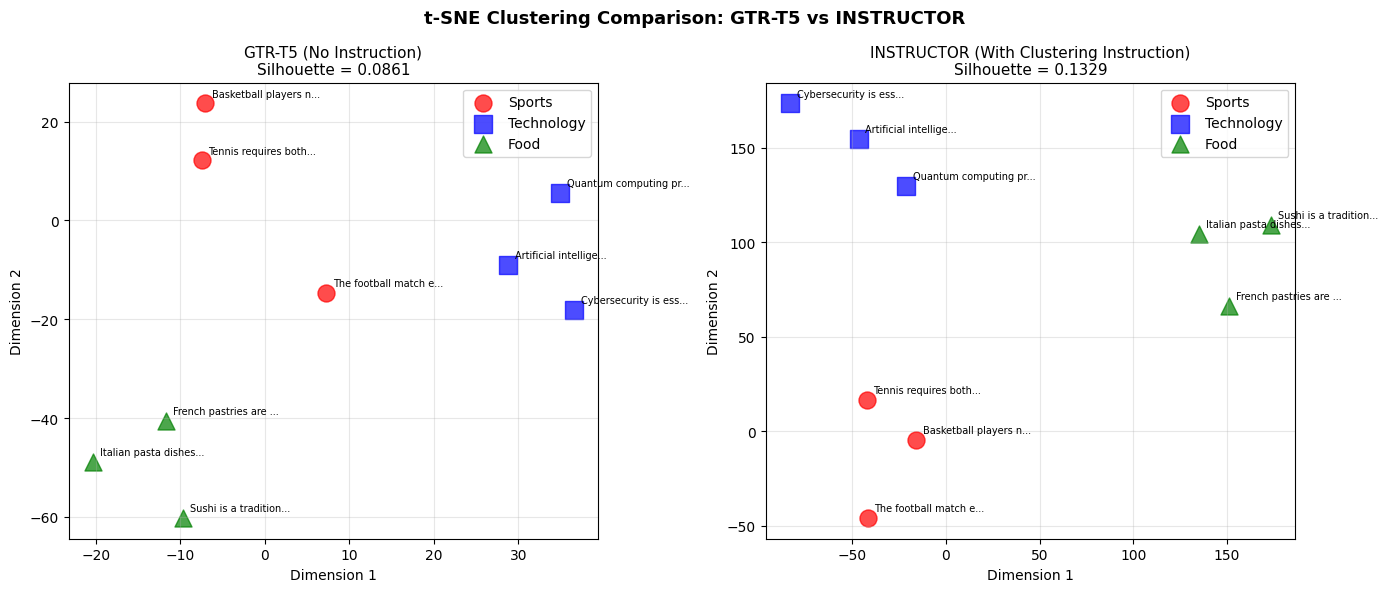


→ INSTRUCTOR với instruction 'Represent the article for topic clustering:' tạo embedding
   phân tách các cụm rõ ràng hơn (Silhouette cao hơn) so với GTR-T5 không có instruction!


In [10]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {0: 'red', 1: 'blue', 2: 'green'}
markers = {0: 'o', 1: 's', 2: '^'}

tsne_gtr = TSNE(n_components=2, random_state=42, perplexity=3)
emb_2d_gtr = tsne_gtr.fit_transform(emb_gtr_cluster)

for i, (x, y, label) in enumerate(zip(emb_2d_gtr[:, 0], emb_2d_gtr[:, 1], true_labels)):
    axes[0].scatter(x, y, c=colors_map[label], marker=markers[label], s=150, alpha=0.7,
                    label=label_names[label] if i % 3 == 0 else "")
    axes[0].annotate(texts_cluster[i][:20] + "...", (x, y), xytext=(5, 5), 
                     textcoords='offset points', fontsize=7)
    
axes[0].set_title('GTR-T5 (No Instruction)\nSilhouette = {:.4f}'.format(sil_gtr), fontsize=11)
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

tsne_inst = TSNE(n_components=2, random_state=42, perplexity=3)
emb_2d_inst = tsne_inst.fit_transform(emb_inst_cluster)

for i, (x, y, label) in enumerate(zip(emb_2d_inst[:, 0], emb_2d_inst[:, 1], true_labels)):
    axes[1].scatter(x, y, c=colors_map[label], marker=markers[label], s=150, alpha=0.7,
                    label=label_names[label] if i % 3 == 0 else "")
    axes[1].annotate(texts_cluster[i][:20] + "...", (x, y), xytext=(5, 5), 
                     textcoords='offset points', fontsize=7)

axes[1].set_title('INSTRUCTOR (With Clustering Instruction)\nSilhouette = {:.4f}'.format(sil_inst), fontsize=11)
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('t-SNE Clustering Comparison: GTR-T5 vs INSTRUCTOR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n→ INSTRUCTOR với instruction 'Represent the article for topic clustering:' tạo embedding")
print("   phân tách các cụm rõ ràng hơn (Silhouette cao hơn) so với GTR-T5 không có instruction!")